## Self Attention Mechanism without trainable weights

In this code block we are going to implement the most simple form of the Self Attention without any trainable weights. <br>

As we have learnt till now: <br>

text corpus -> token ids -> token embeddings -> postional Embedddings -> input embeddings(token+positional) <br>

Till here we have encoded the words semantic meaning and its positional information for the model to learn. <br>

But we also want to encode how a particular word is related to all the other words in the sequence. <br>

i.e. For Predicting a new token which tokens in the input sequence should be given emphasis to.<br>

input embeddings -> context embeddings (input+relative attention)

Here we will use: Embedding dimensions: 3

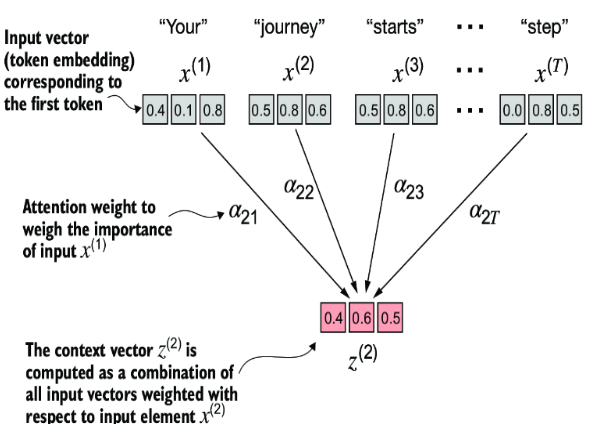

Here x1, x2, x3 .. xT are the input embeddings wrt tokens <br>

a21, a22, a23, a2T are importace of all the other tokens in predicting the token x2 i.e. "journey"<br>

z2 is the context embedding (combinaton of all input vectors weighted wrt input elemnet x2)

The goal of the Self Attention layer is to calculate a context vector (embedding) z(i) for each element x(i).

Context Vector: Enriched Embedding Vector (Semantic+Positional+Relation with other tokens)

### Implementing a simplified Attention Mechanism

Consider the following input seq, which has already been embedded into 3-dimensional vectors.

In [1]:
import torch

inputs = torch.tensor(
  [[0.43, 0.15, 0.89], # Your     (x^1)
   [0.55, 0.87, 0.66], # journey  (x^2)
   [0.57, 0.85, 0.64], # starts   (x^3)
   [0.22, 0.58, 0.33], # with     (x^4)
   [0.77, 0.25, 0.10], # one      (x^5)
   [0.05, 0.80, 0.55]] # step     (x^6)
)

#each of the word token have been converted into a three dimensional embeddings

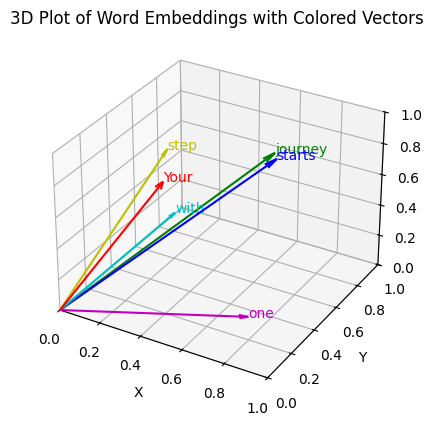

In [2]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Corresponding words
words = ['Your', 'journey', 'starts', 'with', 'one', 'step']

# Extract x, y, z coordinates
x_coords = inputs[:, 0].numpy()
y_coords = inputs[:, 1].numpy()
z_coords = inputs[:, 2].numpy()
# Create 3D plot with vectors from origin to each point, using different colors
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Define a list of colors for the vectors
colors = ['r', 'g', 'b', 'c', 'm', 'y']

# Plot each vector with a different color and annotate with the corresponding word
for (x, y, z, word, color) in zip(x_coords, y_coords, z_coords, words, colors):
    # Draw vector from origin to the point (x, y, z) with specified color and smaller arrow length ratio
    ax.quiver(0, 0, 0, x, y, z, color=color, arrow_length_ratio=0.05)
    ax.text(x, y, z, word, fontsize=10, color=color)

# Set labels for axes
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

# Set plot limits to keep arrows within the plot boundaries
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])
ax.set_zlim([0, 1])

plt.title('3D Plot of Word Embeddings with Colored Vectors')
plt.show()


We will find the context embedding for each word in the sentence "Your Journey Starts with one step". Starting with "journey"<br>

For the 2nd Element **X2**, **(query)** <br>
Corresponding context vector is **Z2** <br>

The input which we are converting to the context embedding is known as **Query**, here "journey". <br>

Z2 is an embedding which contains information about X2 and all other input elements X1 to XT, <br>

Later, we will add trainable weights that help the LLM learn to construct these context vectors; so that they are relevant for the LLM to generate the next token. <br>


1. First task of implementing self-attention is to compute the intermediate values (w), also referred to as attention scores. <br>

    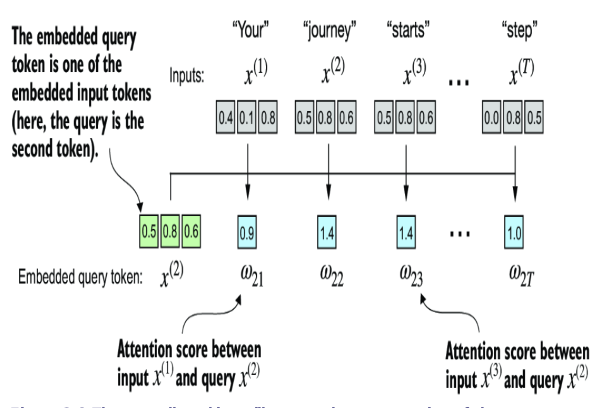 <br>

    The intermediate attention scores are calcukated between the query token and each input token. (Dot Product between query and every other input token) <br>
    Dot product quantifies how much two vectors are aligned. (a.b = |a||b|cos&), the more closer the vectors are, the more attention score they should have cos0 = 1, max val. cos90 = 0, min value 0. 

In the context of self attention mechanisms, dot product determines the extent to which elements of a sequence attend to one another -> higher the dot product, higher the similarity and attention scores between the elements. 


In [3]:
#2nd input token is the query
query = inputs[1] #journey

attn_scores_2 = torch.empty(inputs.shape[0])

for i, x_i in enumerate(inputs):
    attn_scores_2[i] = torch.dot(x_i, query) #dot product between each input vector with the query

print(attn_scores_2)  

tensor([0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865])


2. In the next step, we normalize each of the attention socres that we computed previously. 

    The main goal behind the normalization is to obtain attention weights that sum up to 1.

    This normalization is a convention that is useful for interpretation and for maintaining training stability in an LLM.

    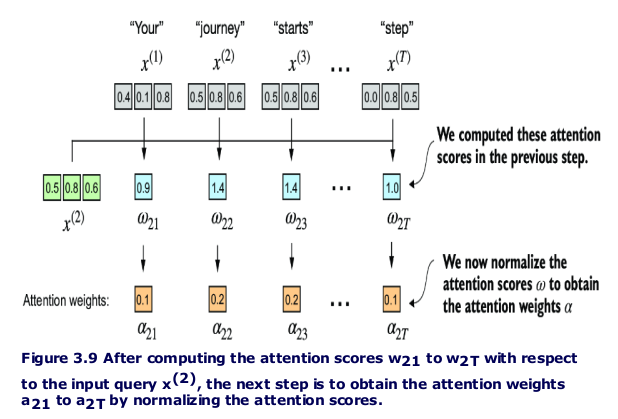
    
    Here's a straightforward method for achieving this normalization step:



In [4]:
attn_weights_2_tmp = attn_scores_2 / attn_scores_2.sum()

print("Attention Weights:", attn_weights_2_tmp)
print("Sum:", attn_weights_2_tmp.sum())


#the difference between attention scores and attn weights is that weights sum up to 1 
# but scores dont

Attention Weights: tensor([0.1455, 0.2278, 0.2249, 0.1285, 0.1077, 0.1656])
Sum: tensor(1.0000)


In practice, it's more common and advisable to use the softmax function for normalization.

This approach is better at managing extreme values and offers more favorable gradient properties during training.

Below is a basic implementation of the softmax function for normalizing the attention scores:

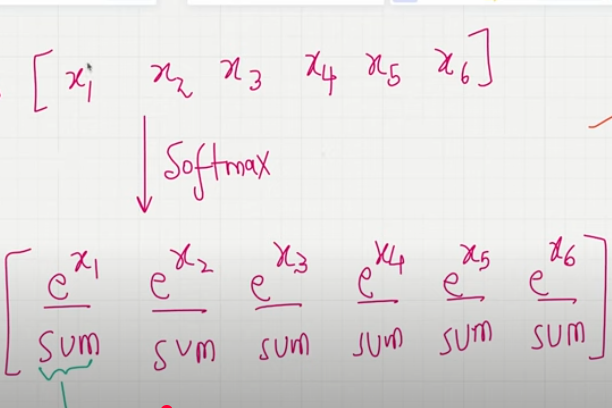
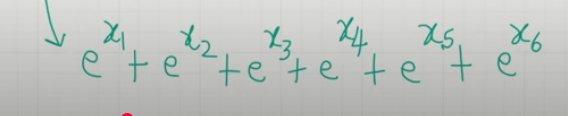

Pytorch Implementation: It subtracts all the values with the max value before expo operations

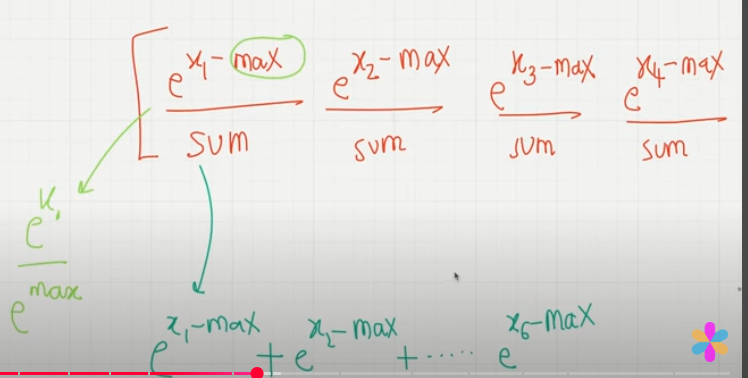

**How Pytorch Implements Softmax? Important**

In [5]:
def softmax_naive(x):
    return torch.exp(x) / torch.exp(x).sum(dim=0)

attn_weights_2_naive = softmax_naive(attn_scores_2)

print("Attention weights:", attn_weights_2_naive)
print("Sum:", attn_weights_2_naive.sum())

Attention weights: tensor([0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581])
Sum: tensor(1.)


As the output shows, the softmax function also meets the objective and normalizes the attention weights such that they sum to 1:

In addition, the softmax function ensures that the attention weights are always positive. This makes the output interpretable as probabilities or relative importance, where higher weights indicate greater importance.

Note that this naive softmax implementation (softmax_naive) may encounter numerical instability problems, such as overflow and underflow, when dealing with large or small input values.

Therefore, in practice, it's advisable to use the PyTorch implementation of softmax, which has been extensively optimized for performance:

In [6]:
attn_weights_2 = torch.softmax(attn_scores_2, dim=0)
print("Attention weights:", attn_weights_2)
print("Sum:", attn_weights_2.sum())

Attention weights: tensor([0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581])
Sum: tensor(1.)


3. After computing the normalized attention weights, we calculate the context vector Z(2) by multiplying the embedded input tokens X(i), with the corresponding attention weights and then summing the resultant vectors. Which will give us the context vector for the token "journey"

    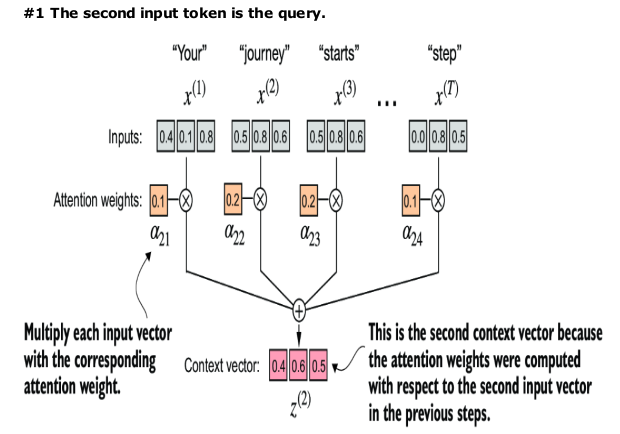

In [7]:
query = inputs[1] # 2nd input token is the query

context_vec_2 = torch.zeros(query.shape)
for i,x_i in enumerate(inputs):
    context_vec_2 += attn_weights_2[i]*x_i

print(context_vec_2)

tensor([0.4419, 0.6515, 0.5683])


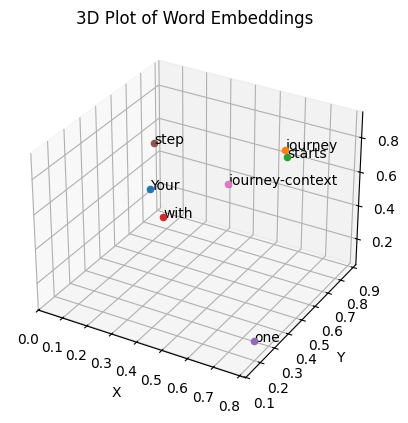

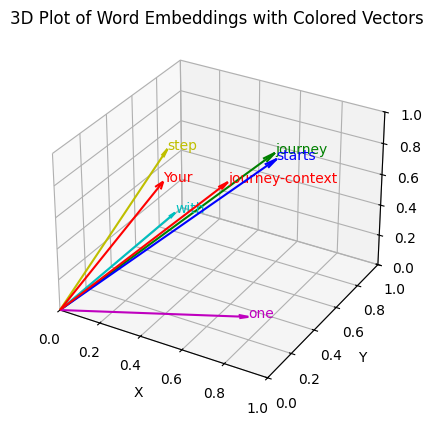

In [8]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

inputs = torch.tensor(
  [[0.43, 0.15, 0.89], # Your     (x^1)
   [0.55, 0.87, 0.66], # journey  (x^2)
   [0.57, 0.85, 0.64], # starts   (x^3)
   [0.22, 0.58, 0.33], # with     (x^4)
   [0.77, 0.25, 0.10], # one      (x^5)
   [0.05, 0.80, 0.55], # step     (x^6)
   [0.4419, 0.6515, 0.5683]]
)

# Corresponding words
words = ['Your', 'journey', 'starts', 'with', 'one', 'step', 'journey-context']

# Extract x, y, z coordinates
x_coords = inputs[:, 0].numpy()
y_coords = inputs[:, 1].numpy()
z_coords = inputs[:, 2].numpy()

# Create 3D plot
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Plot each point and annotate with corresponding word
for x, y, z, word in zip(x_coords, y_coords, z_coords, words):
    ax.scatter(x, y, z)
    ax.text(x, y, z, word, fontsize=10)

# Set labels for axes
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

plt.title('3D Plot of Word Embeddings')
plt.show()

# Create 3D plot with vectors from origin to each point, using different colors
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Define a list of colors for the vectors
colors = ['r', 'g', 'b', 'c', 'm', 'y', 'r']

# Plot each vector with a different color and annotate with the corresponding word
for (x, y, z, word, color) in zip(x_coords, y_coords, z_coords, words, colors):
    # Draw vector from origin to the point (x, y, z) with specified color and smaller arrow length ratio
    ax.quiver(0, 0, 0, x, y, z, color=color, arrow_length_ratio=0.05)
    ax.text(x, y, z, word, fontsize=10, color=color)

# Set labels for axes
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

# Set plot limits to keep arrows within the plot boundaries
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])
ax.set_zlim([0, 1])

plt.title('3D Plot of Word Embeddings with Colored Vectors')
plt.show()

4. Computing attention weights for all input tokens 

    We can extend similiar computation as before to calculate attention weights and context vectors for all inputs. 

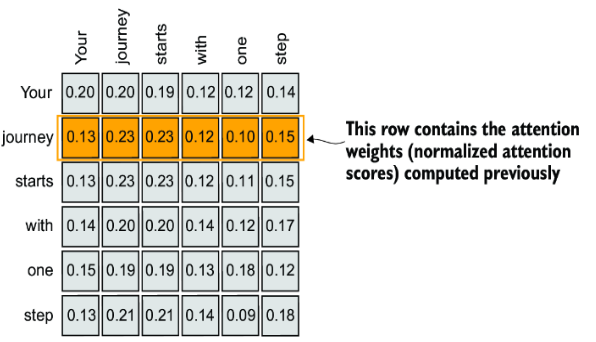

Attention Weight Matrix

We will follow the exact same 3 steps as before

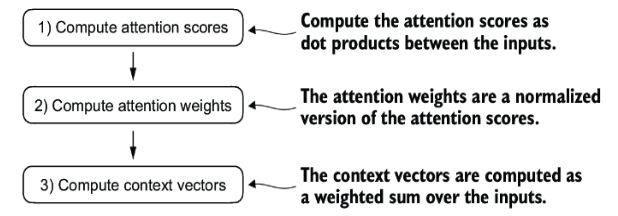


Now, we can extend this computation to calculate attention weights and context vectors for all inputs.

First, we add an additional for-loop to compute the dot products for all pairs of inputs.

In [9]:
attn_scores = torch.empty(len(inputs), len(inputs))
for i, x_i in enumerate(inputs):
    for j, x_j in enumerate(inputs):
        attn_scores[i, j] = torch.dot(x_i, x_j)

print(attn_scores)

tensor([[0.9995, 0.9544, 0.9422, 0.4753, 0.4576, 0.6310, 0.7935],
        [0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865, 1.1849],
        [0.9422, 1.4754, 1.4570, 0.8296, 0.7154, 1.0605, 1.1694],
        [0.4753, 0.8434, 0.8296, 0.4937, 0.3474, 0.6565, 0.6626],
        [0.4576, 0.7070, 0.7154, 0.3474, 0.6654, 0.2935, 0.5600],
        [0.6310, 1.0865, 1.0605, 0.6565, 0.2935, 0.9450, 0.8559],
        [0.7935, 1.1849, 1.1694, 0.6626, 0.5600, 0.8559, 0.9427]])


Each element in the preceding tensor represents an attention score between each pair of inputs.

When computing the preceding attention score tensor, we used for-loops in Python.

However, for-loops are generally slow, and we can achieve the same results using matrix multiplication:

In [10]:
attn_scores = inputs @ inputs.T
print(attn_scores)

tensor([[0.9995, 0.9544, 0.9422, 0.4753, 0.4576, 0.6310, 0.7935],
        [0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865, 1.1849],
        [0.9422, 1.4754, 1.4570, 0.8296, 0.7154, 1.0605, 1.1694],
        [0.4753, 0.8434, 0.8296, 0.4937, 0.3474, 0.6565, 0.6626],
        [0.4576, 0.7070, 0.7154, 0.3474, 0.6654, 0.2935, 0.5600],
        [0.6310, 1.0865, 1.0605, 0.6565, 0.2935, 0.9450, 0.8559],
        [0.7935, 1.1849, 1.1694, 0.6626, 0.5600, 0.8559, 0.9427]])


We now normalize each row so that the values in each row sum to 1:

In [11]:
attn_weights = torch.softmax(attn_scores, dim=-1)
print(attn_weights)

tensor([[0.1792, 0.1713, 0.1692, 0.1061, 0.1042, 0.1240, 0.1459],
        [0.1180, 0.2026, 0.1986, 0.1056, 0.0921, 0.1346, 0.1486],
        [0.1184, 0.2017, 0.1981, 0.1058, 0.0943, 0.1332, 0.1485],
        [0.1223, 0.1768, 0.1744, 0.1246, 0.1077, 0.1467, 0.1476],
        [0.1305, 0.1675, 0.1689, 0.1169, 0.1607, 0.1108, 0.1446],
        [0.1180, 0.1861, 0.1813, 0.1211, 0.0842, 0.1615, 0.1478],
        [0.1277, 0.1889, 0.1860, 0.1121, 0.1011, 0.1359, 0.1483]])


In the context of using PyTorch, the dim parameter in functions like torch.softmax specifies the dimension of the input tensor along which the function will be computed.

By setting dim=-1, we are instructing the softmax function to apply the normalization along the last dimension of the attn_scores tensor. 2-D (x,y) y is last so y

If attn_scores is a 2D tensor (for example, with a shape of [rows, columns]), dim=-1 will normalize across the columns so that the values in each row (summing over the column dimension) sum up to 1. each row will sum up to 1

In [12]:
row_2_sum = sum([0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581])
print("Row 2 sum:", row_2_sum)
print("All row sums:", attn_weights.sum(dim=-1))

Row 2 sum: 1.0
All row sums: tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000])


In the third and last step, we now use these attention weights to compute all context vectors via matrix multiplication

In [13]:
all_context_vecs = attn_weights @ inputs
print(all_context_vecs)

tensor([[0.4420, 0.6016, 0.5774],
        [0.4419, 0.6515, 0.5683],
        [0.4429, 0.6499, 0.5673],
        [0.4321, 0.6330, 0.5536],
        [0.4635, 0.5997, 0.5326],
        [0.4213, 0.6505, 0.5651],
        [0.4397, 0.6372, 0.5635]])


In [14]:
#We can double-check that the code is correct by comparing the 2nd row with the context vector
#  z(2) calculated previously

print("Previous 2nd context vector:", context_vec_2)

Previous 2nd context vector: tensor([0.4419, 0.6515, 0.5683])
